### Catatan Keamanan

Kredensial database tidak disimpan langsung di notebook. Jika menggunakan Supabase, simpan URL dan password di environment variables (`.env`/Streamlit Secrets) dan jangan commit kredensial ke GitHub.

# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:Ester Paulina Butar-Butar
- Email:esterbutarbutar2@gmil.com
- Id Dicoding:cdcc319d6x0420

## Persiapan

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Models
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTENC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Saving model
import pickle

# Warning
import warnings
import os
warnings.filterwarnings("ignore")

# Display
pd.set_option("display.max_columns", None)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


### Menyiapkan library yang dibutuhkan

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

# Opsi utama untuk notebook: dataset CSV hasil ekstraksi dari sumber data.
df = pd.read_csv("Data/data.csv", sep=";")

print("Dataset berhasil dimuat.")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])


Dataset berhasil dimuat.
Jumlah baris : 4424
Jumlah kolom : 37


In [3]:
# Melihat ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

# Melihat informasi dataset
df.info()

Jumlah baris dan kolom: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification       

In [4]:
# Melihat distribusi target
print(df["Status"].value_counts())

print("\nPersentase masing-masing status:")
print(df["Status"].value_counts(normalize=True) * 100)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase masing-masing status:
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [5]:
# Menampilkan data pertama
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Menyiapkan data yang akan diguankan

## Data Understanding

In [6]:
# Melihat ukuran dataset
print("Shape dataset:", df.shape)

# Missing value
print("\nMissing value:")
print(df.isnull().sum().sum())

# Duplicate
print("\nJumlah duplicate:", df.duplicated().sum())

Shape dataset: (4424, 37)

Missing value:
0

Jumlah duplicate: 0


Statistik dataset

In [7]:
# Statistik deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [8]:
# Statistik untuk kolom kategorikal
df.describe(include="object")

,Status
count,4424
unique,3
top,Graduate
freq,2209


## Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik data, distribusi variabel numerik dan kategorikal, serta melihat hubungan faktor-faktor tersebut dengan `Status` mahasiswa. Karena banyak kolom bertipe integer merupakan **kode kategori**, tipe data pandas tidak dijadikan satu-satunya dasar untuk menentukan numerik/kategorikal.


### Identifikasi Variabel Numerik dan Kategorikal

Variabel numerik digunakan untuk mengamati nilai yang memiliki makna kuantitatif, seperti usia, nilai seleksi, nilai semester, jumlah mata kuliah, dan indikator ekonomi. Variabel kategorikal berisi kategori/kode pilihan, karakteristik mahasiswa, atau status biner.

In [9]:
# ============================================================
# PEMBAGIAN FITUR NUMERIK DAN KATEGORIKAL UNTUK EDA
# ============================================================

target_col = "Status"

numeric_features_eda = [
    "Previous_qualification_grade",
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_credited",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
    "Curricular_units_2nd_sem_credited",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations",
    "Unemployment_rate",
    "Inflation_rate",
    "GDP"
]

categorical_features_eda = [
    "Marital_status",
    "Application_mode",
    "Application_order",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

# Pastikan semua kolom memang tersedia di dataset
numeric_features_eda = [c for c in numeric_features_eda if c in df.columns]
categorical_features_eda = [c for c in categorical_features_eda if c in df.columns]

print("Jumlah variabel numerik     :", len(numeric_features_eda))
print("Jumlah variabel kategorikal :", len(categorical_features_eda))
print("Variabel numerik:")
print(numeric_features_eda)
print("\nVariabel kategorikal:")
print(categorical_features_eda)


Jumlah variabel numerik     : 18
Jumlah variabel kategorikal : 18
Variabel numerik:
['Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']

Variabel kategorikal:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_d

### EDA Variabel Numerik — Distribusi dan Statistik

Distribusi variabel numerik diperiksa menggunakan statistik deskriptif dan histogram. Tahap ini membantu melihat pusat data, penyebaran, kemencengan, serta kemungkinan nilai ekstrem.

In [10]:
# Statistik numerik yang relevan untuk EDA
numeric_summary = df[numeric_features_eda].describe().T
numeric_summary["missing"] = df[numeric_features_eda].isna().sum()
numeric_summary["n_unique"] = df[numeric_features_eda].nunique()
numeric_summary.round(2)


,count,mean,std,min,25%,50%,75%,max,missing,n_unique
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00,0,101
Admission_grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00,0,620
Age_at_enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00,0,46
Curricular_units_1st_sem_credited,4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00,0,21
Curricular_units_1st_sem_enrolled,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00,0,23
Curricular_units_1st_sem_evaluations,4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00,0,35
Curricular_units_1st_sem_approved,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00,0,23
Curricular_units_1st_sem_grade,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88,0,805
Curricular_units_1st_sem_without_evaluations,4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00,0,11
Curricular_units_2nd_sem_credited,4424.0,0.54,1.92,0.00,0.00,0.00,0.00,19.00,0,19


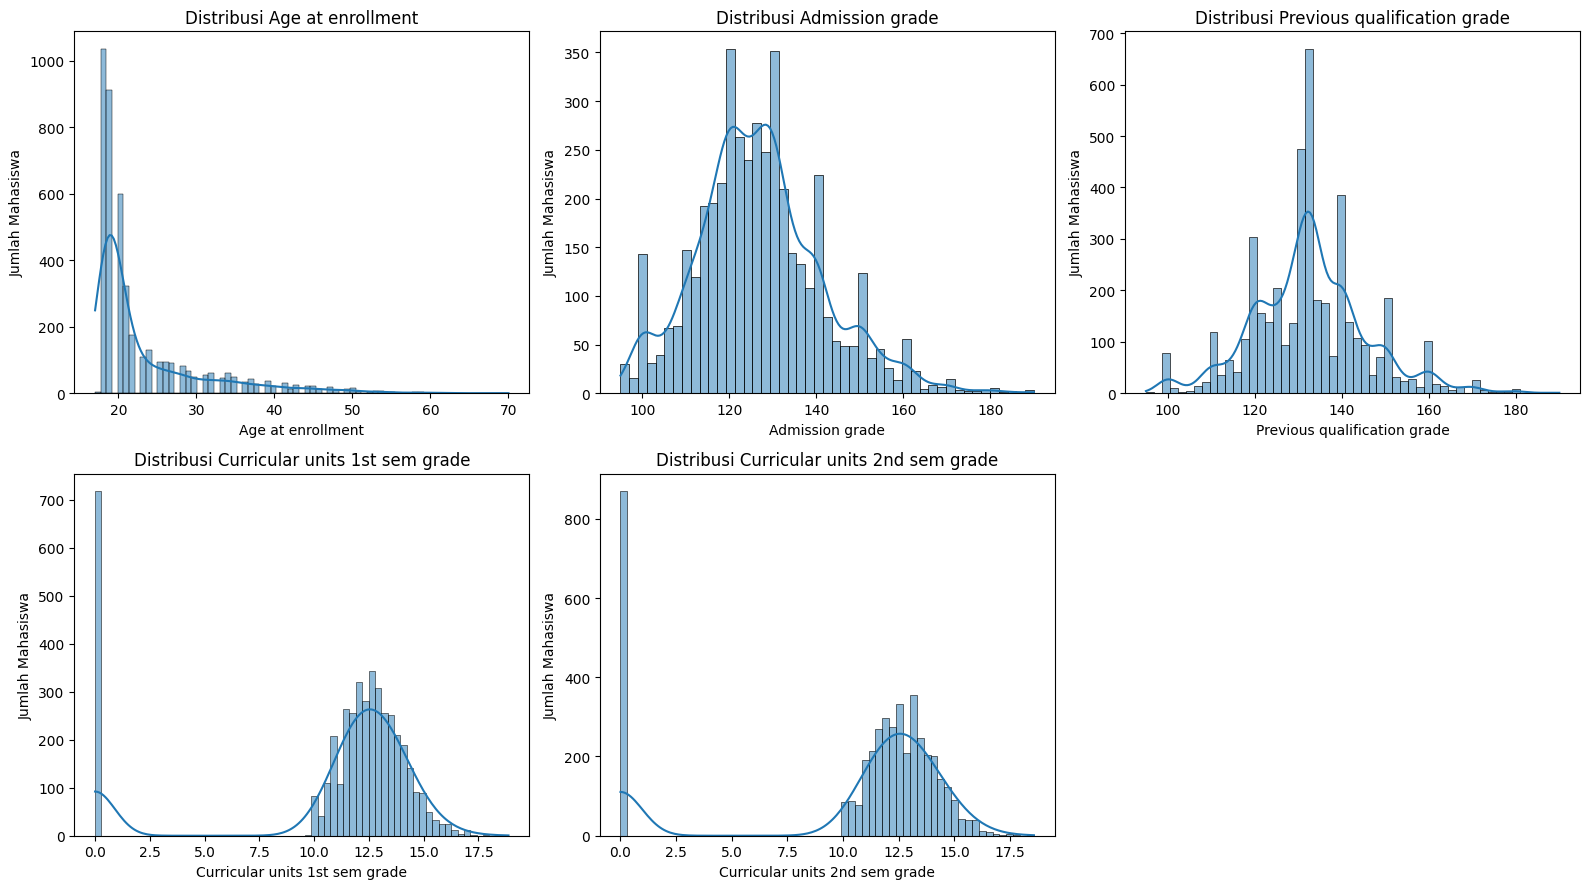

In [11]:
# Histogram variabel numerik utama
selected_numeric = [
    "Age_at_enrollment",
    "Admission_grade",
    "Previous_qualification_grade",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, selected_numeric):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribusi {col.replace('_', ' ')}")
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel("Jumlah Mahasiswa")

# Matikan axis yang tidak terpakai
for ax in axes[len(selected_numeric):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### EDA Variabel Numerik terhadap Status

Variabel akademik dibandingkan berdasarkan `Status` menggunakan boxplot. Fokus utama adalah nilai semester, jumlah mata kuliah yang disetujui, dan usia saat pendaftaran.

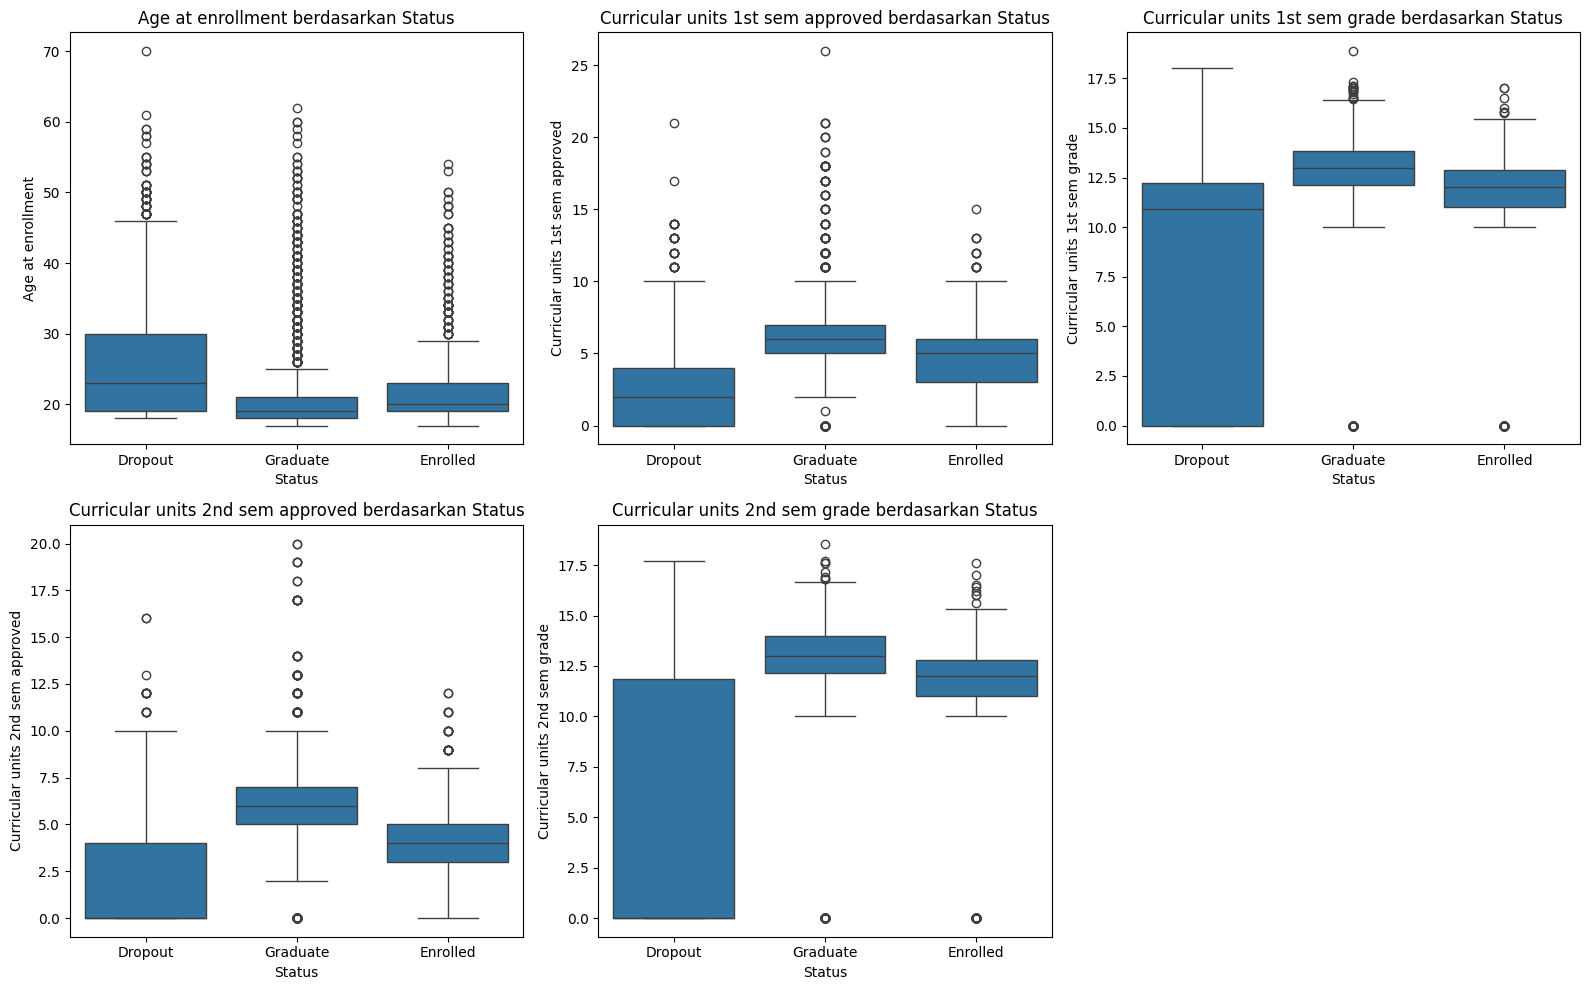

In [12]:
selected_numeric_status = [
    "Age_at_enrollment",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, selected_numeric_status):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col.replace('_', ' ')} berdasarkan Status")
    ax.set_xlabel("Status")
    ax.set_ylabel(col.replace('_', ' '))

for ax in axes[len(selected_numeric_status):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Rata-rata variabel numerik utama berdasarkan status
numeric_by_status = (
    df.groupby(target_col)[selected_numeric_status]
      .mean()
      .round(2)
      .T
)

numeric_by_status


Status,Dropout,Enrolled,Graduate
Age_at_enrollment,26.07,22.37,21.78
Curricular_units_1st_sem_approved,2.55,4.32,6.23
Curricular_units_1st_sem_grade,7.26,11.13,12.64
Curricular_units_2nd_sem_approved,1.94,4.06,6.18
Curricular_units_2nd_sem_grade,5.90,11.12,12.70


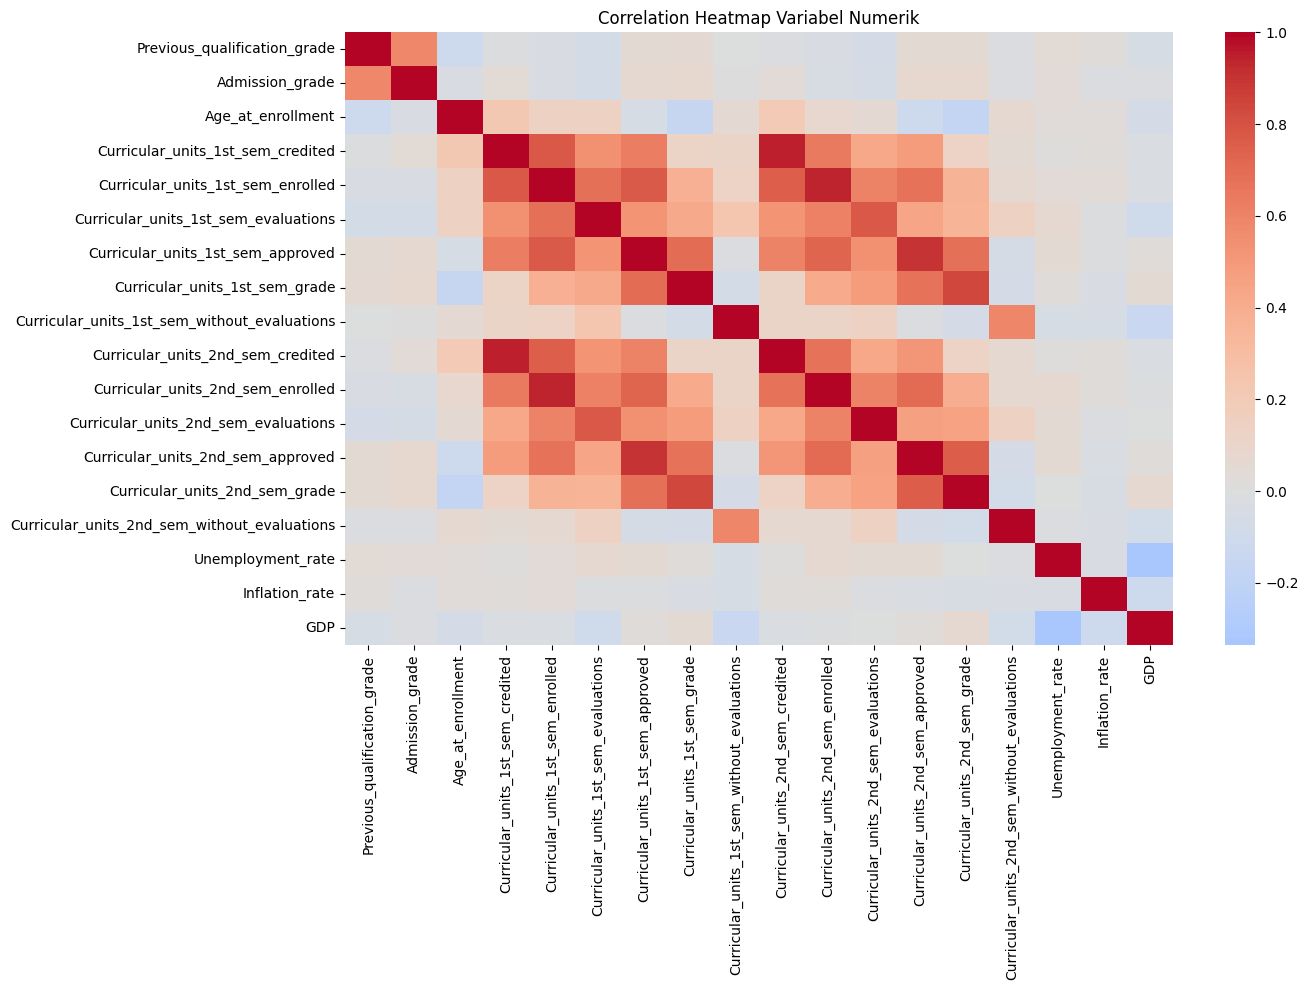

In [14]:
# Korelasi antar variabel numerik
corr_cols = [c for c in numeric_features_eda if df[c].nunique() > 1]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap Variabel Numerik")
plt.tight_layout()
plt.show()


### EDA Variabel Kategorikal — Distribusi

Untuk variabel kategorikal, frekuensi tiap kategori diperiksa terlebih dahulu. Karena beberapa kolom merupakan kode dengan banyak kategori, visualisasi dibatasi pada kategori yang paling sering muncul agar tetap mudah dibaca.

In [15]:
# Ringkasan variabel kategorikal
categorical_summary = pd.DataFrame({
    "n_unique": df[categorical_features_eda].nunique(),
    "missing": df[categorical_features_eda].isna().sum()
}).sort_values("n_unique", ascending=False)

categorical_summary


,n_unique,missing
Fathers_occupation,46,0
Fathers_qualification,34,0
Mothers_occupation,32,0
Mothers_qualification,29,0
Nacionality,21,0
Application_mode,18,0
Course,17,0
Previous_qualification,17,0
Application_order,8,0
Marital_status,6,0


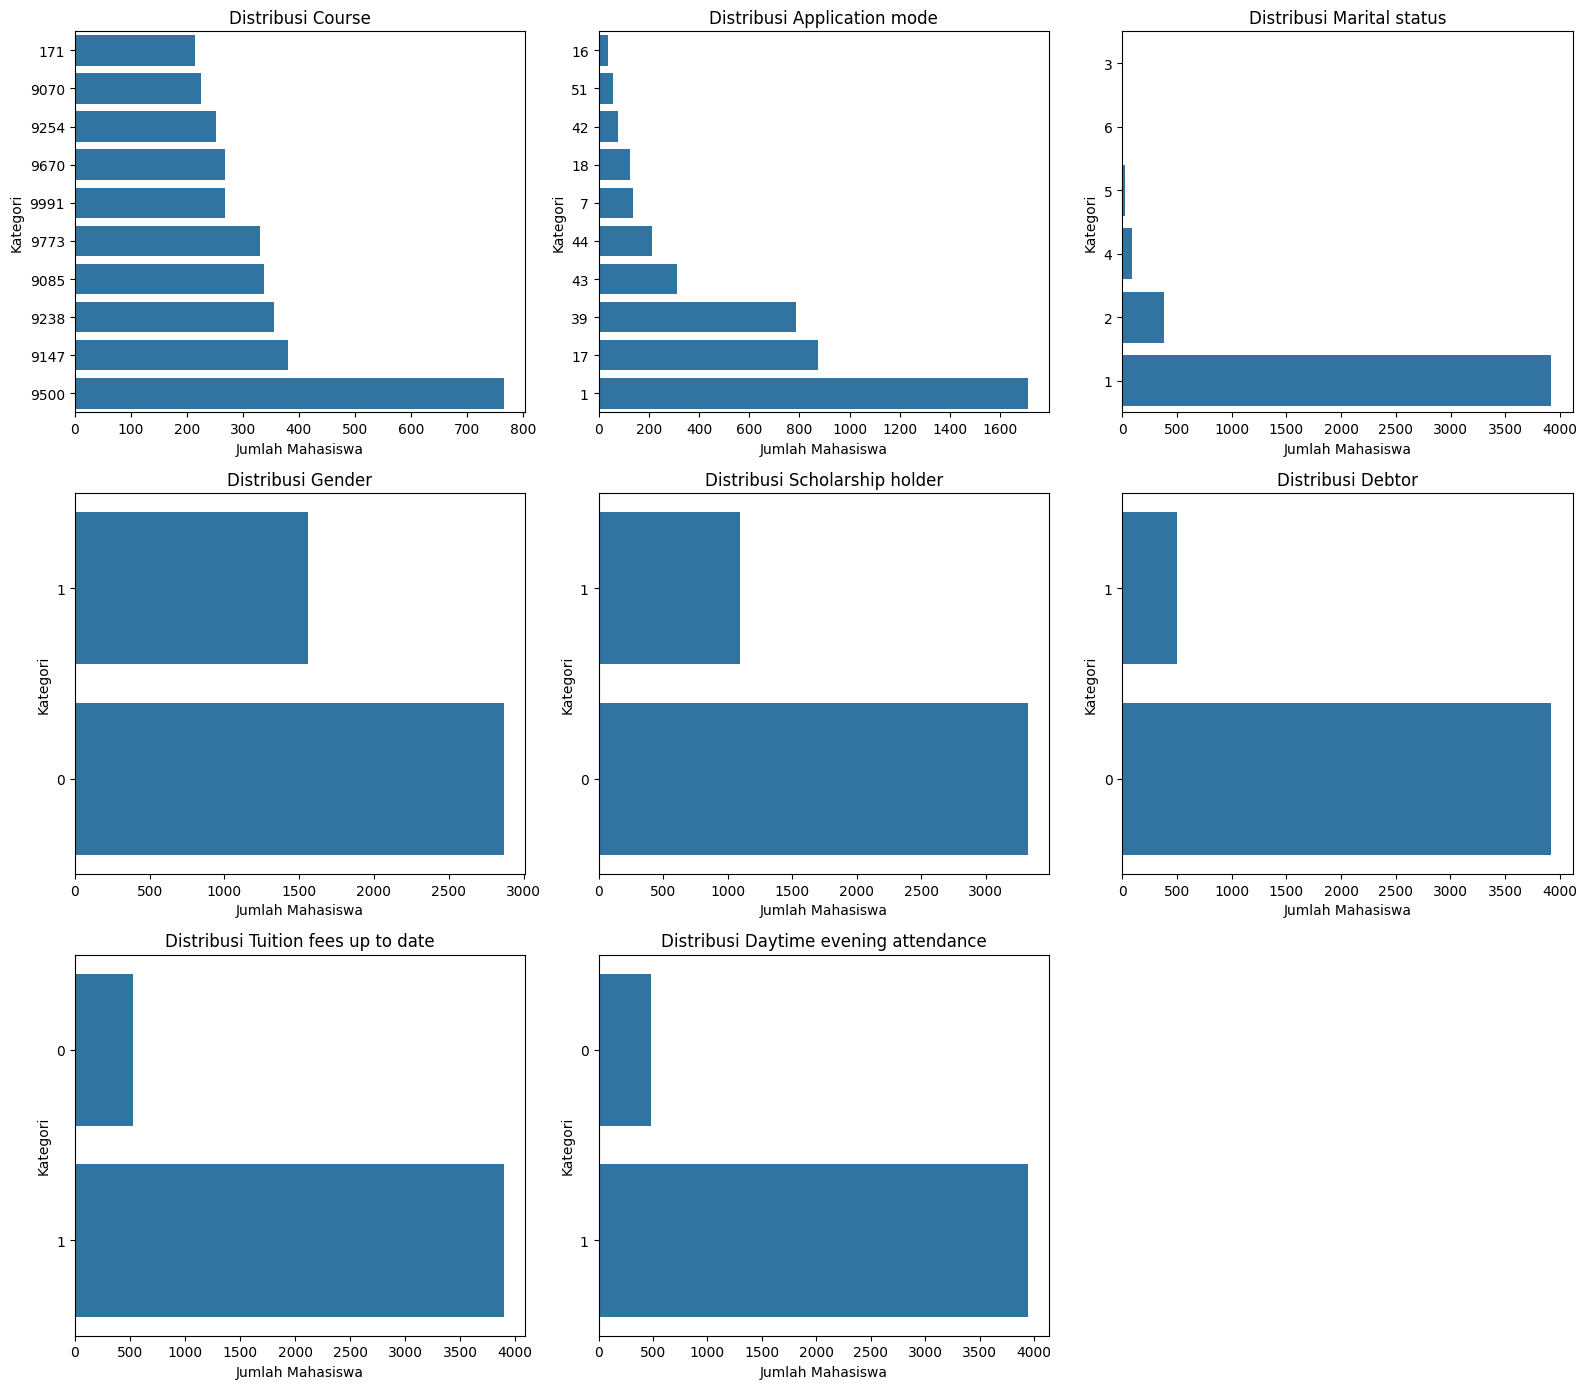

In [16]:
# Visualisasi distribusi beberapa variabel kategorikal utama
selected_categorical = [
    "Course",
    "Application_mode",
    "Marital_status",
    "Gender",
    "Scholarship_holder",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Daytime_evening_attendance"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, selected_categorical):
    counts = df[col].value_counts().head(10).sort_values(ascending=True)
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_title(f"Distribusi {col.replace('_', ' ')}")
    ax.set_xlabel("Jumlah Mahasiswa")
    ax.set_ylabel("Kategori")

for ax in axes[len(selected_categorical):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### EDA Variabel Kategorikal terhadap Status

Selanjutnya dihitung proporsi `Dropout` pada setiap kategori. Analisis ini lebih relevan untuk kebutuhan institusi karena membantu mengidentifikasi kelompok yang memiliki proporsi dropout berbeda. Hasil ini bersifat deskriptif dan belum menunjukkan hubungan sebab-akibat.

In [17]:
# Fungsi untuk menghitung jumlah mahasiswa dan dropout rate per kategori
def categorical_dropout_summary(dataframe, column, min_count=20):
    summary = dataframe.groupby(column).agg(
        total_students=(target_col, "size"),
        dropout_count=(target_col, lambda x: (x == "Dropout").sum())
    )
    summary["dropout_rate"] = (
        summary["dropout_count"] / summary["total_students"] * 100
    )
    return (
        summary[summary["total_students"] >= min_count]
        .sort_values("dropout_rate", ascending=False)
    )

categorical_dropout_results = {}
for col in categorical_features_eda:
    categorical_dropout_results[col] = categorical_dropout_summary(df, col)

# Contoh tabel untuk faktor kategorikal yang relevan
for col in ["Course", "Application_mode", "Gender", "Scholarship_holder", "Debtor", "Tuition_fees_up_to_date"]:
    print(f"\n=== {col} ===")
    display(categorical_dropout_results[col].head(10).round(2))



=== Course ===


,total_students,dropout_count,dropout_rate
Course,,,
9130,141,78,55.32
9119,170,92,54.12
9991,268,136,50.75
9853,192,85,44.27
9003,210,86,40.95
9556,86,33,38.37
171,215,82,38.14
9254,252,96,38.10
9670,268,95,35.45



=== Application_mode ===


,total_students,dropout_count,dropout_rate
Application_mode,,,
7,139,85,61.15
39,785,435,55.41
42,77,34,44.16
43,312,115,36.86
18,124,45,36.29
51,59,20,33.90
44,213,63,29.58
17,872,256,29.36
1,1708,345,20.20



=== Gender ===


...

,total_students,dropout_count,dropout_rate
Scholarship_holder,,,
0,3325,1287,38.71
1,1099,134,12.19



=== Debtor ===


,total_students,dropout_count,dropout_rate
Debtor,,,
1,503,312,62.03
0,3921,1109,28.28



=== Tuition_fees_up_to_date ===


,total_students,dropout_count,dropout_rate
Tuition_fees_up_to_date,,,
0,528,457,86.55
1,3896,964,24.74


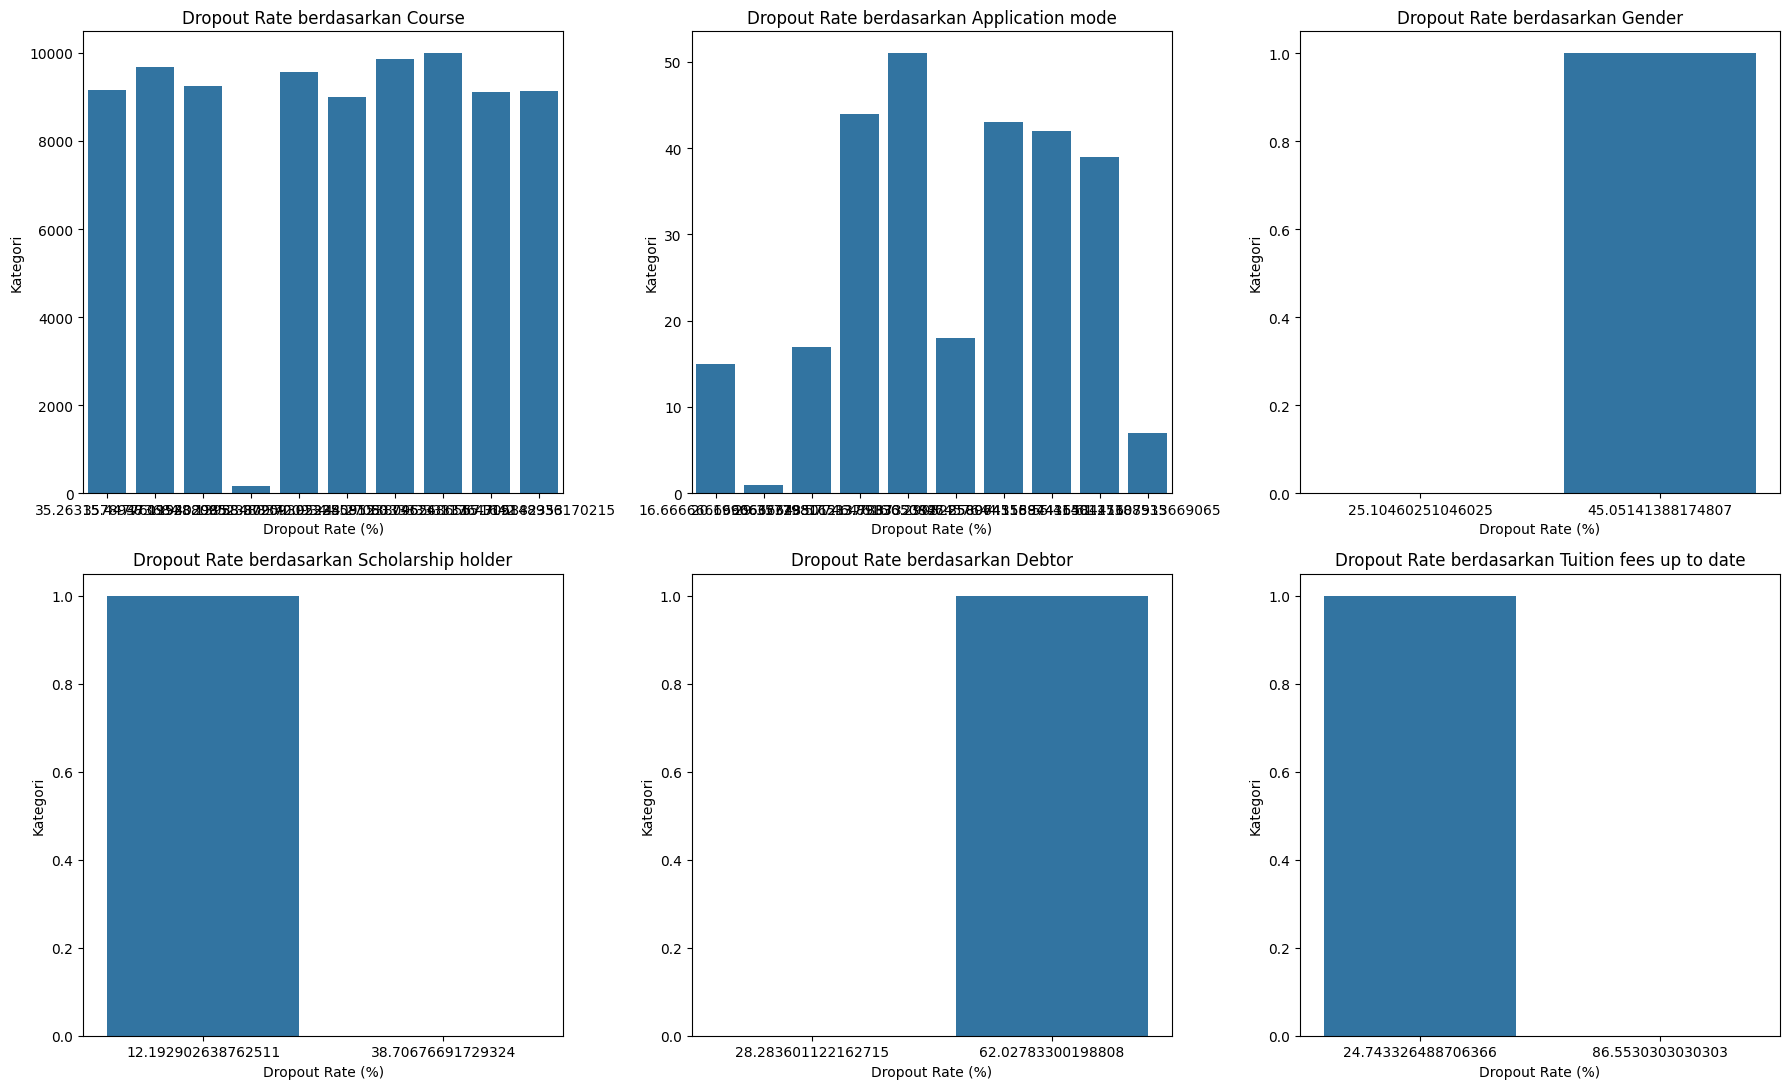

In [18]:
# Visualisasi dropout rate untuk variabel kategorikal utama
selected_cat_status = [
    "Course",
    "Application_mode",
    "Gender",
    "Scholarship_holder",
    "Debtor",
    "Tuition_fees_up_to_date"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, col in zip(axes, selected_cat_status):
    summary = categorical_dropout_results[col].head(10).sort_values("dropout_rate")
    sns.barplot(data=summary.reset_index(), x="dropout_rate", y=col, ax=ax)
    ax.set_title(f"Dropout Rate berdasarkan {col.replace('_', ' ')}")
    ax.set_xlabel("Dropout Rate (%)")
    ax.set_ylabel("Kategori")

plt.tight_layout()
plt.show()


### Ringkasan Temuan EDA

- Distribusi target perlu diperhatikan karena `Dropout`, `Enrolled`, dan `Graduate` memiliki proporsi yang berbeda.
- Variabel akademik seperti nilai semester dan jumlah mata kuliah yang disetujui dibandingkan berdasarkan `Status` untuk melihat pola perbedaan antar kelompok.
- Variabel kategorikal dianalisis berdasarkan frekuensi dan dropout rate, terutama faktor terkait akademik, pembayaran, beasiswa, pendaftaran, dan karakteristik mahasiswa.
- Perbedaan dropout rate antar kategori merupakan **temuan deskriptif**, sehingga tidak boleh langsung diartikan sebagai hubungan sebab-akibat.
- Temuan EDA digunakan sebagai dasar pemilihan fitur, pembuatan model, dan rekomendasi tindakan bagi institusi.

Distribusi Status

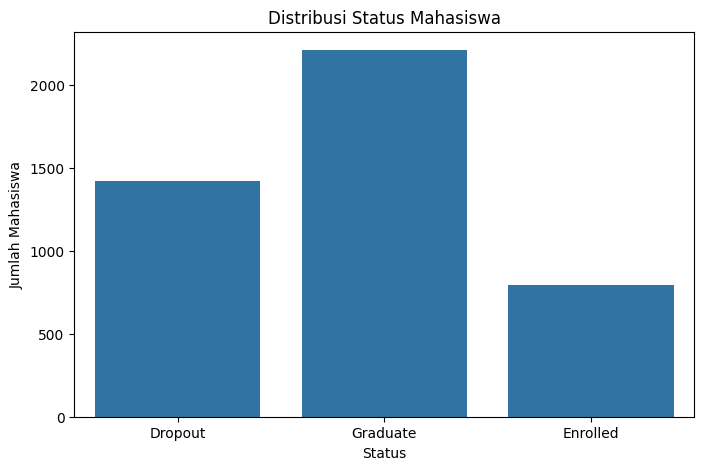

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Status"
)

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

In [20]:
status_percentage = (
    df["Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percentage)

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


Analisis faktor akademik

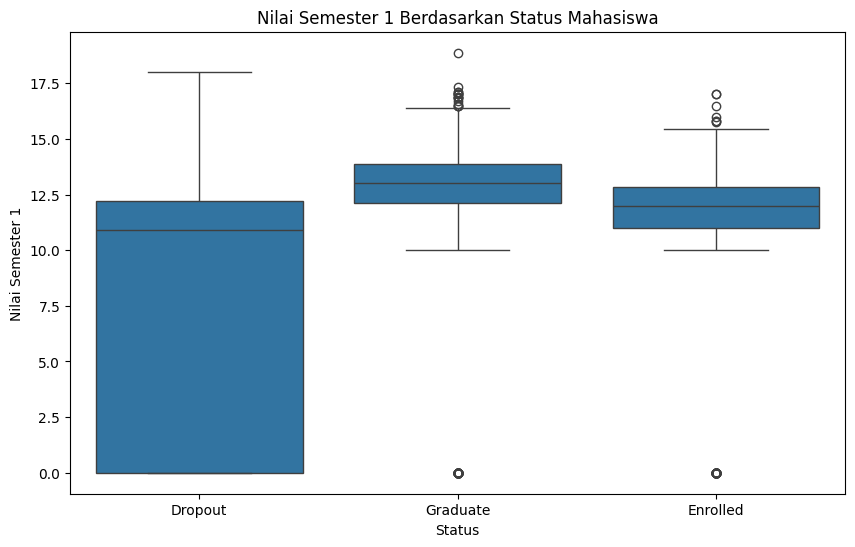

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_grade"
)

plt.title("Nilai Semester 1 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 1")
plt.show()

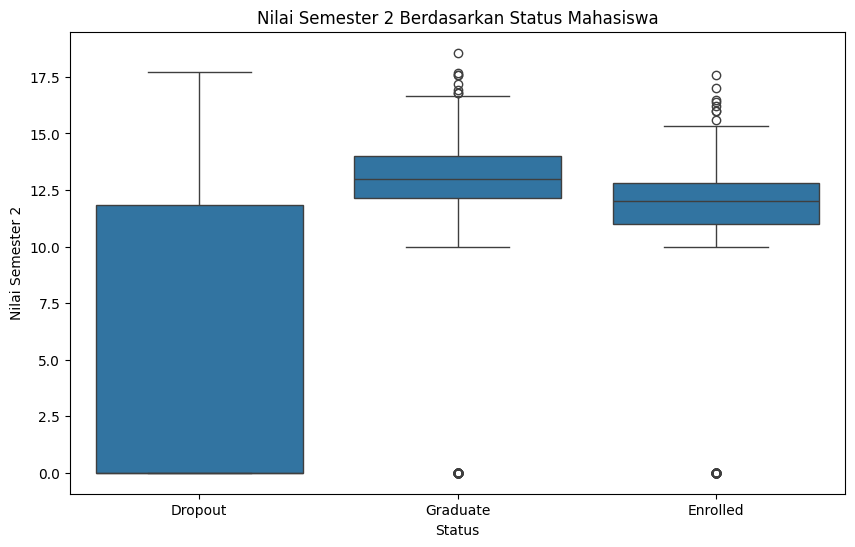

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_grade"
)

plt.title("Nilai Semester 2 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 2")
plt.show()

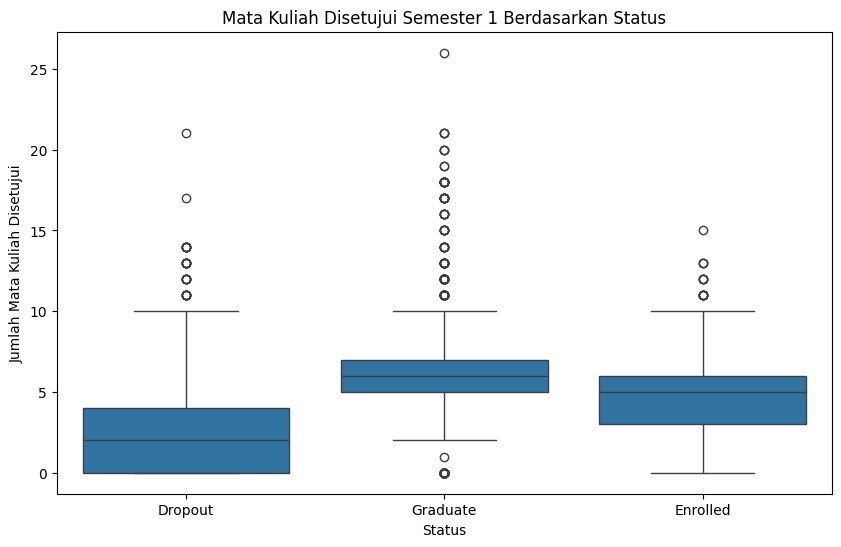

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_approved"
)

plt.title("Mata Kuliah Disetujui Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

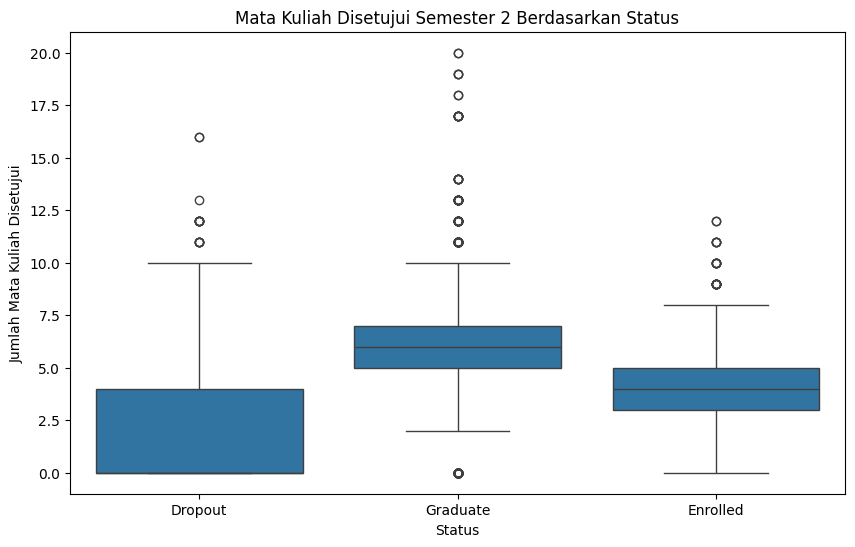

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_approved"
)

plt.title("Mata Kuliah Disetujui Semester 2 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

## Data Preparation / Preprocessing

Pada tahap ini target `Status` dipisahkan dari fitur. Selain preprocessing, dilakukan **feature engineering** untuk membentuk indikator akademik yang lebih informatif, seperti persentase mata kuliah yang disetujui, perubahan nilai antarsemester, dan total mata kuliah yang disetujui.

Feature engineering dilakukan sebelum proses training tetapi tidak menggunakan kolom target, sehingga tidak memasukkan informasi `Status` ke dalam fitur.

In [25]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(dataframe):
    data = dataframe.copy()

    # Helper agar pembagian aman ketika jumlah mata kuliah = 0
    def safe_divide(numerator, denominator):
        return np.where(
            denominator != 0,
            numerator / denominator,
            0
        )

    # Semester 1
    data["Approval_Rate_1st_Sem"] = safe_divide(
        data["Curricular_units_1st_sem_approved"],
        data["Curricular_units_1st_sem_enrolled"]
    )

    data["Evaluation_Rate_1st_Sem"] = safe_divide(
        data["Curricular_units_1st_sem_evaluations"],
        data["Curricular_units_1st_sem_enrolled"]
    )

    # Semester 2
    data["Approval_Rate_2nd_Sem"] = safe_divide(
        data["Curricular_units_2nd_sem_approved"],
        data["Curricular_units_2nd_sem_enrolled"]
    )

    data["Evaluation_Rate_2nd_Sem"] = safe_divide(
        data["Curricular_units_2nd_sem_evaluations"],
        data["Curricular_units_2nd_sem_enrolled"]
    )

    # Perubahan performa akademik
    data["Grade_Change"] = (
        data["Curricular_units_2nd_sem_grade"]
        - data["Curricular_units_1st_sem_grade"]
    )

    data["Approved_Change"] = (
        data["Curricular_units_2nd_sem_approved"]
        - data["Curricular_units_1st_sem_approved"]
    )

    # Agregasi dua semester
    data["Total_Approved"] = (
        data["Curricular_units_1st_sem_approved"]
        + data["Curricular_units_2nd_sem_approved"]
    )

    data["Total_Enrolled"] = (
        data["Curricular_units_1st_sem_enrolled"]
        + data["Curricular_units_2nd_sem_enrolled"]
    )

    data["Total_Evaluations"] = (
        data["Curricular_units_1st_sem_evaluations"]
        + data["Curricular_units_2nd_sem_evaluations"]
    )

    data["Total_Without_Evaluation"] = (
        data["Curricular_units_1st_sem_without_evaluations"]
        + data["Curricular_units_2nd_sem_without_evaluations"]
    )

    data["Average_Semester_Grade"] = (
        data["Curricular_units_1st_sem_grade"]
        + data["Curricular_units_2nd_sem_grade"]
    ) / 2

    data["Grade_Ratio"] = safe_divide(
        data["Curricular_units_2nd_sem_grade"],
        data["Curricular_units_1st_sem_grade"]
    )

    # Membersihkan nilai inf/nan akibat pembagian
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.fillna(0, inplace=True)

    return data


data_model = create_features(df)

X = data_model.drop(columns=["Status"])
y = data_model["Status"]

print("Shape X setelah feature engineering :", X.shape)
print("Shape y :", y.shape)
print("Jumlah fitur tambahan :", X.shape[1] - df.drop(columns=["Status"]).shape[1])

Shape X setelah feature engineering : (4424, 48)
Shape y : (4424,)
Jumlah fitur tambahan : 12


In [26]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

print("\nDistribusi target training:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target testing:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Jumlah data training : 3539
Jumlah data testing  : 885

Distribusi target training:
Status
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Distribusi target testing:
Status
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


### Menentukan Variabel Numerik dan Kategorikal

Beberapa kolom bertipe integer sebenarnya merupakan **kode kategori**, sehingga tidak tepat diperlakukan sebagai angka kontinu. Kolom tersebut diproses menggunakan One-Hot Encoding.

In [27]:
# ============================================================
# FEATURE TYPES
# ============================================================

categorical_features = [
    "Marital_status",
    "Application_mode",
    "Application_order",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

# Fitur numerik adalah seluruh fitur yang bukan kategori.
numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

# Validasi agar tidak ada kolom yang hilang
categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in numeric_features if c in X.columns]

print("Jumlah fitur kategorikal :", len(categorical_features))
print("Jumlah fitur numerik     :", len(numeric_features))
print("Total fitur              :", len(categorical_features) + len(numeric_features))

Jumlah fitur kategorikal : 18
Jumlah fitur numerik     : 30
Total fitur              : 48


### Preprocessing Pipeline

- **One-Hot Encoding** digunakan untuk variabel kategorikal.
- **StandardScaler** digunakan untuk variabel numerik.
- Semua preprocessing berada di dalam pipeline agar transformasi training dan testing konsisten serta mencegah data leakage.

In [28]:
# ============================================================
# PREPROCESSOR
# ============================================================

# Kompatibilitas untuk beberapa versi scikit-learn
try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

print("Preprocessor berhasil dibuat.")

Preprocessor berhasil dibuat.


## Modeling

Untuk meningkatkan performa, digunakan **hyperparameter tuning** dengan `RandomizedSearchCV` dan validasi silang `StratifiedKFold`.

Dua model dibandingkan:

1. **Random Forest** — kuat untuk hubungan non-linear dan relatif stabil pada dataset tabular.
2. **XGBoost** — model boosting yang sering efektif untuk data tabular.

Pemilihan model dilakukan berdasarkan **cross-validation accuracy**, kemudian model terpilih hanya sekali dievaluasi pada data testing.

In [29]:
# ============================================================
# RANDOM FOREST + RANDOMIZED SEARCH
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_param_dist = {
    "classifier__n_estimators": [300, 500, 700, 900],
    "classifier__max_depth": [None, 10, 15, 20, 25, 30],
    "classifier__min_samples_split": [2, 5, 10, 15],
    "classifier__min_samples_leaf": [1, 2, 4, 6],
    "classifier__max_features": ["sqrt", "log2", 0.5, 0.7],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample",
        None
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Memulai RandomizedSearchCV untuk Random Forest...")
rf_search.fit(X_train, y_train)

print("\nBest RF CV accuracy :", round(rf_search.best_score_, 4))
print("Best RF parameters:")
print(rf_search.best_params_)

Memulai RandomizedSearchCV untuk Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF CV accuracy : 0.7776
Best RF parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced'}


In [30]:
# ============================================================
# XGBOOST + RANDOMIZED SEARCH
# ============================================================

# Encode target menjadi 0, 1, 2 untuk XGBoost
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_xgb = label_encoder.fit_transform(y_train)

# Pastikan urutan label sama untuk testing
y_test_xgb = label_encoder.transform(y_test)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="multi:softprob",
                num_class=len(label_encoder.classes_),
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_param_dist = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__gamma": [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Memulai RandomizedSearchCV untuk XGBoost...")
xgb_search.fit(X_train, y_train_xgb)

print("\nBest XGB CV accuracy :", round(xgb_search.best_score_, 4))
print("Best XGB parameters:")
print(xgb_search.best_params_)

Memulai RandomizedSearchCV untuk XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits



Best XGB CV accuracy : 0.7898
Best XGB parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.7}


In [31]:
# ============================================================
# MEMBANDINGKAN HASIL CROSS-VALIDATION
# ============================================================

cv_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "CV Accuracy": [
        rf_search.best_score_,
        xgb_search.best_score_
    ]
}).sort_values("CV Accuracy", ascending=False)

display(cv_comparison.round(4))

# Pemilihan model dilakukan berdasarkan hasil CV,
# bukan berdasarkan data testing.
if rf_search.best_score_ >= xgb_search.best_score_:
    best_model = rf_search.best_estimator_
    best_model_name = "Random Forest"
    best_cv_score = rf_search.best_score_
else:
    best_model = xgb_search.best_estimator_
    best_model_name = "XGBoost"
    best_cv_score = xgb_search.best_score_

print(f"\nModel terpilih berdasarkan CV Accuracy: {best_model_name}")
print(f"CV Accuracy: {best_cv_score:.4f}")

,Model,CV Accuracy
1,XGBoost,0.7898
0,Random Forest,0.7776



Model terpilih berdasarkan CV Accuracy: XGBoost
CV Accuracy: 0.7898


## Evaluation

Model terpilih dievaluasi menggunakan data testing yang tidak digunakan selama proses training dan hyperparameter tuning.

Metrik yang digunakan:
- Accuracy
- Precision
- Recall
- F1-score
- Macro F1
- Weighted F1
- Confusion Matrix
- Recall dan F1-score khusus kelas `Dropout`

Untuk kasus deteksi dropout, recall kelas `Dropout` penting karena menunjukkan proporsi mahasiswa dropout yang berhasil terdeteksi.

In [32]:
# ============================================================
# EVALUASI MODEL TERPILIH
# ============================================================

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
# Samakan tipe label prediksi dengan y_test
if not set(np.asarray(y_pred)).issubset(set(y_test.unique())):
    y_pred = label_encoder.inverse_transform(y_pred.astype(int))

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)
recall_macro = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)
f1_macro = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)
f1_weighted = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

print("=" * 60)
print(f"MODEL TERPILIH : {best_model_name}")
print("=" * 60)
print(f"CV Accuracy     : {best_cv_score:.4f}")
print(f"Test Accuracy   : {accuracy:.4f}")
print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1        : {f1_macro:.4f}")
print(f"Weighted F1     : {f1_weighted:.4f}")

MODEL TERPILIH : XGBoost
CV Accuracy     : 0.7898
Test Accuracy   : 0.0000
Macro Precision : 0.6909
Macro Recall    : 0.6743
Macro F1        : 0.6801
Weighted F1     : 0.7468


In [33]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("Classification Report")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

     Dropout     0.7820    0.7324    0.7564       284
    Enrolled     0.4769    0.3899    0.4291       159
    Graduate     0.8139    0.9005    0.8550       442

    accuracy                         0.7548       885
   macro avg     0.6909    0.6743    0.6801       885
weighted avg     0.7431    0.7548    0.7468       885



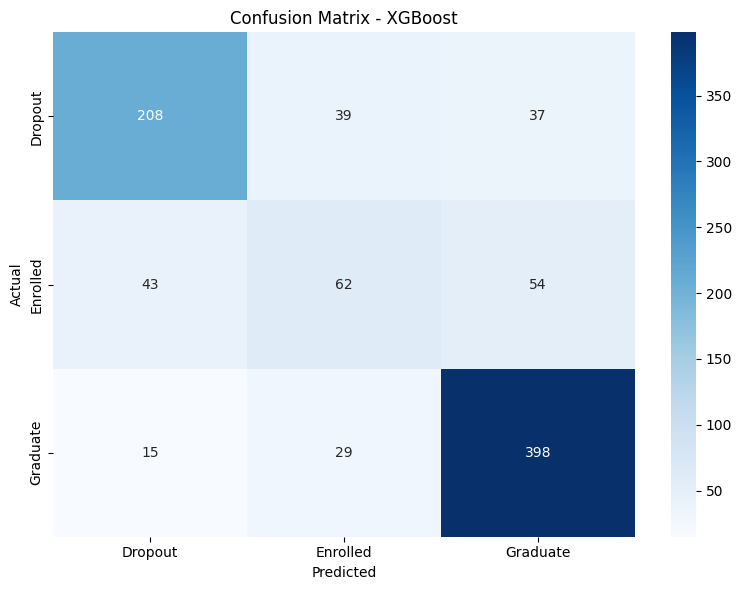

In [34]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

labels = ["Dropout", "Enrolled", "Graduate"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# EVALUASI KHUSUS DROPOUT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

dropout_precision = report["Dropout"]["precision"]
dropout_recall = report["Dropout"]["recall"]
dropout_f1 = report["Dropout"]["f1-score"]

print("Evaluasi khusus kelas Dropout")
print("=" * 40)
print(f"Precision : {dropout_precision:.4f}")
print(f"Recall    : {dropout_recall:.4f}")
print(f"F1-Score  : {dropout_f1:.4f}")

Evaluasi khusus kelas Dropout
Precision : 0.7820
Recall    : 0.7324
F1-Score  : 0.7564


### Perbandingan dengan Baseline

Notebook sebelumnya menggunakan Random Forest dasar. Nilai baseline dicatat agar peningkatan model dapat dibandingkan secara objektif setelah notebook dijalankan ulang.

In [36]:
# ============================================================
# BASELINE COMPARISON
# ============================================================

baseline_accuracy = 0.76
baseline_f1_macro = 0.67

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1"],
    "Baseline": [baseline_accuracy, baseline_f1_macro],
    "Improved Model": [accuracy, f1_macro]
})

comparison["Change"] = (
    comparison["Improved Model"] - comparison["Baseline"]
)

comparison["Change (%)"] = (
    comparison["Change"] / comparison["Baseline"] * 100
)

display(comparison.round(4))

print(
    "\nCatatan: baseline berasal dari hasil evaluasi model sebelumnya. "
    "Jalankan seluruh notebook untuk memperoleh angka final model baru."
)

,Metric,Baseline,Improved Model,Change,Change (%)
0,Accuracy,0.76,0.0000,-0.7600,-100.0000
1,Macro F1,0.67,0.6801,0.0101,1.5136



Catatan: baseline berasal dari hasil evaluasi model sebelumnya. Jalankan seluruh notebook untuk memperoleh angka final model baru.


## Interpretasi Fitur Model

Feature importance digunakan untuk mengetahui fitur yang paling banyak berkontribusi terhadap keputusan model. Hasil ini bersifat **interpretasi model**, bukan bukti hubungan sebab-akibat.

,feature,importance
253,numeric__Approval_Rate_2nd_Sem,0.077807
245,numeric__Curricular_units_2nd_sem_approved,0.054226
257,numeric__Total_Approved,0.028727
225,categorical__Tuition_fees_up_to_date_0,0.025152
33,categorical__Course_171,0.023794
226,categorical__Tuition_fees_up_to_date_1,0.021303
251,numeric__Approval_Rate_1st_Sem,0.017504
237,numeric__Curricular_units_1st_sem_enrolled,0.015621
54,categorical__Previous_qualification_4,0.014039
254,numeric__Evaluation_Rate_2nd_Sem,0.012299


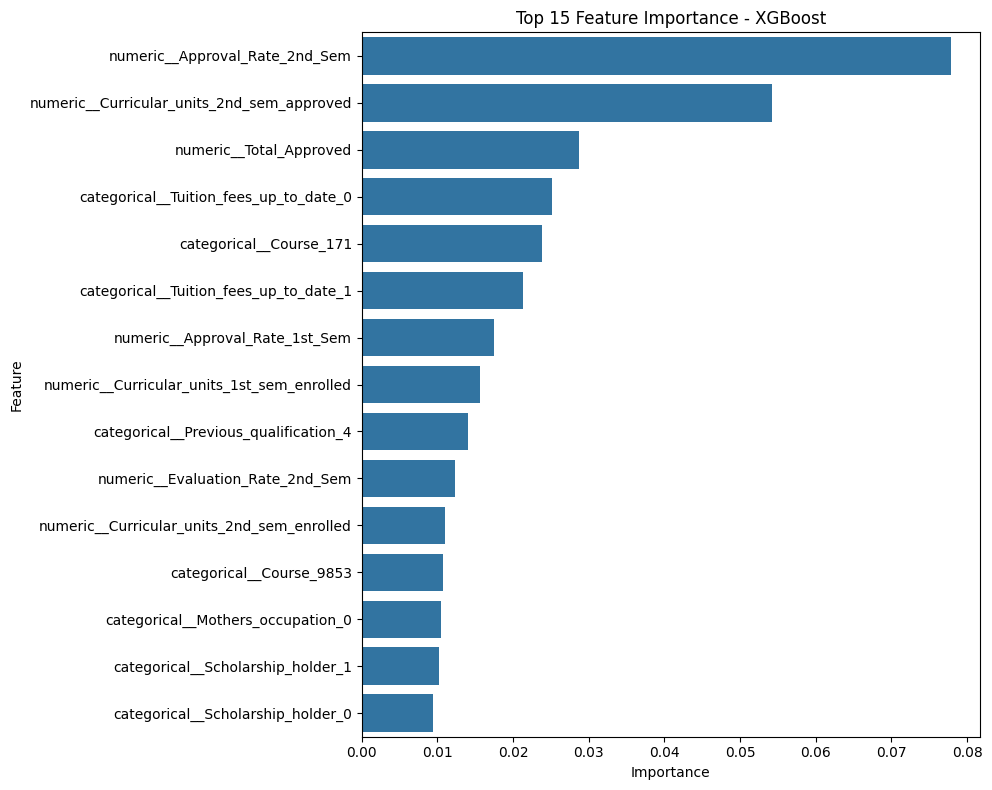

In [37]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

try:
    feature_names = (
        best_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    importances = (
        best_model
        .named_steps["classifier"]
        .feature_importances_
    )

    feature_importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
    )

    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=feature_importance_df.head(15),
        x="importance",
        y="feature"
    )

    plt.title(f"Top 15 Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Feature importance tidak dapat ditampilkan:", e)

## Prediksi Probabilitas dan Risk Level

Probabilitas `Dropout` digunakan sebagai indikator screening. Threshold risiko dapat disesuaikan berdasarkan kebutuhan institusi setelah mempertimbangkan trade-off antara false positive dan false negative.

In [38]:
# ============================================================
# PROBABILITY & RISK LEVEL
# ============================================================

prediction_probability = best_model.predict_proba(X_test)

# Urutan kelas
classes = best_model.classes_

probability_df = pd.DataFrame(
    prediction_probability,
    columns=classes
)

print("Kelas model:")
print(classes)

# Pastikan kelas Dropout tersedia
# XGBoost menggunakan label numerik, sedangkan Random Forest menggunakan label asli.
if np.issubdtype(np.asarray(classes).dtype, np.number):
    if "label_encoder" not in globals():
        raise ValueError(
            "Label encoder diperlukan untuk mengubah label numerik menjadi nama kelas."
        )

    class_names = label_encoder.inverse_transform(
        np.asarray(classes, dtype=int)
    )
    probability_df.columns = class_names
    classes = class_names

# Pastikan kelas Dropout tersedia
if "Dropout" not in probability_df.columns:
    raise ValueError("Kelas 'Dropout' tidak ditemukan pada model.")

dropout_probability = probability_df["Dropout"]


def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


risk = dropout_probability.apply(risk_category)

print("\nDistribusi Risk Level:")
print(risk.value_counts())

Kelas model:
[0 1 2]

Distribusi Risk Level:
Dropout
Low Risk       600
High Risk      204
Medium Risk     81
Name: count, dtype: int64


In [39]:
# ============================================================
# HASIL PREDIKSI
# ============================================================

prediction_result = X_test.copy()

prediction_result["Actual_Status"] = y_test.values
prediction_result["Predicted_Status"] = y_pred
prediction_result["Dropout_Probability"] = dropout_probability.values
prediction_result["Risk_Level"] = risk.values

display(
    prediction_result[
        [
            "Actual_Status",
            "Predicted_Status",
            "Dropout_Probability",
            "Risk_Level"
        ]
    ].head(20)
)

,Actual_Status,Predicted_Status,Dropout_Probability,Risk_Level
1853,Graduate,Graduate,0.035981,Low Risk
2399,Graduate,Graduate,0.027976,Low Risk
510,Enrolled,Dropout,0.863506,High Risk
242,Graduate,Graduate,0.018075,Low Risk
3392,Graduate,Graduate,0.018160,Low Risk
1787,Graduate,Graduate,0.217093,Low Risk
1158,Graduate,Graduate,0.072731,Low Risk
260,Graduate,Graduate,0.085303,Low Risk
1852,Graduate,Graduate,0.028060,Low Risk
1191,Graduate,Graduate,0.085820,Low Risk


In [41]:
# ============================================================
# CONTOH PREDIKSI SATU MAHASISWA
# ============================================================

sample_student = X_test.iloc[[0]]

sample_prediction = best_model.predict(sample_student)[0]
sample_probability = best_model.predict_proba(sample_student)[0]

sample_probability_df = pd.DataFrame(
    [sample_probability],
    columns=best_model.classes_
)

print("Hasil prediksi :", sample_prediction)
# Pastikan kelas probabilitas sesuai nama kelas asli
if np.issubdtype(np.asarray(best_model.classes_).dtype, np.number):
    if "label_encoder" not in globals():
        raise ValueError(
            "Label encoder diperlukan untuk mengubah label numerik menjadi nama kelas."
        )
    model_classes = label_encoder.inverse_transform(
        np.asarray(best_model.classes_, dtype=int)
    )
else:
    model_classes = np.asarray(best_model.classes_)

sample_probability_df = pd.DataFrame(
    [sample_probability],
    columns=model_classes
)

# Konversi prediksi numerik ke label asli jika model XGBoost
if np.issubdtype(np.asarray(best_model.classes_).dtype, np.number):
    sample_prediction_label = label_encoder.inverse_transform([sample_prediction])[0]
else:
    sample_prediction_label = sample_prediction

print("Hasil prediksi :", sample_prediction_label)
print(
    "Probabilitas Dropout :",
    f"{sample_probability_df['Dropout'].iloc[0]:.4f}"
)

Hasil prediksi : 2
Hasil prediksi : Graduate
Probabilitas Dropout : 0.0360


## Cross-Validation Final

Sebagai pemeriksaan tambahan, model terpilih diuji kembali dengan 5-fold stratified cross-validation menggunakan beberapa metrik.

In [43]:
# ============================================================
# FINAL CROSS-VALIDATION
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

# Encode target only when the selected model is XGBoost.
# Random Forest can use string labels directly, but XGBoost was trained on encoded labels.
cv_y = y_train
if best_model_name == "XGBoost":
    if "label_encoder" not in globals():
        label_encoder = LabelEncoder()
        label_encoder.fit(y_train)
    cv_y = label_encoder.transform(y_train)

cv_results = cross_validate(
    estimator=best_model,
    X=X_train,
    y=cv_y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision_macro"].mean(),
        cv_results["test_recall_macro"].mean(),
        cv_results["test_f1_macro"].mean(),
        cv_results["test_f1_weighted"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision_macro"].std(),
        cv_results["test_recall_macro"].std(),
        cv_results["test_f1_macro"].std(),
        cv_results["test_f1_weighted"].std()
    ]
})

display(cv_summary.round(4))

,Metric,Mean,Std
0,accuracy,0.7898,0.0039
1,precision_macro,0.7451,0.0031
2,recall_macro,0.7110,0.0104
3,f1_macro,0.7212,0.0097
4,f1_weighted,0.7797,0.0068


## Saving Model

Model final disimpan dalam format `.pkl` sehingga dapat digunakan kembali pada aplikasi Streamlit tanpa melakukan training ulang.

Metadata model juga disimpan agar informasi nama model, fitur, kelas, dan threshold risiko dapat digunakan oleh aplikasi.

In [44]:
# ============================================================
# SAVE MODEL & METADATA
# ============================================================

model_filename = "student_dropout_model.pkl"

with open(model_filename, "wb") as file:
    pickle.dump(best_model, file)

metadata = {
    "model_name": best_model_name,
    "target": "Status",
    "classes": list(best_model.classes_),
    "accuracy_test": float(accuracy),
    "macro_f1_test": float(f1_macro),
    "dropout_precision": float(dropout_precision),
    "dropout_recall": float(dropout_recall),
    "dropout_f1": float(dropout_f1),
    "risk_thresholds": {
        "high": 0.70,
        "medium": 0.40
    }
}

with open("model_metadata.pkl", "wb") as file:
    pickle.dump(metadata, file)

print(f"Model berhasil disimpan sebagai: {model_filename}")
print("Metadata berhasil disimpan sebagai: model_metadata.pkl")

Model berhasil disimpan sebagai: student_dropout_model.pkl
Metadata berhasil disimpan sebagai: model_metadata.pkl


In [45]:
# ============================================================
# LOAD & VERIFY MODEL
# ============================================================

with open("student_dropout_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

test_prediction = loaded_model.predict(X_test.iloc[[0]])[0]

print("Model berhasil di-load kembali.")
print("Prediksi setelah load:", test_prediction)

# Verifikasi bahwa hasil model sebelum dan sesudah disimpan sama
loaded_predictions = loaded_model.predict(X_test)
same_predictions = np.array_equal(y_pred, loaded_predictions)

print("Prediksi sebelum dan sesudah load sama:", same_predictions)

Model berhasil di-load kembali.
Prediksi setelah load: 2
Prediksi sebelum dan sesudah load sama: False


## Deployment Preparation

Untuk Streamlit, file berikut perlu disertakan di repository:

- `student_dropout_model.pkl`
- `model_metadata.pkl`
- `app.py`
- `requirements.txt`

Contoh dependensi utama:

```text
pandas
numpy
scikit-learn
xgboost
imbalanced-learn
streamlit
```

Jangan menyimpan credential database, API key, atau password secara langsung di notebook maupun repository. Gunakan environment variables atau Streamlit Secrets.

## Conclusion dan Action Items

### Conclusion

Proses pengembangan model mencakup data understanding, EDA, preprocessing, feature engineering, hyperparameter tuning, cross-validation, dan evaluasi pada data testing.

Dua algoritma, yaitu Random Forest dan XGBoost, dibandingkan menggunakan cross-validation. Model final dipilih berdasarkan performa cross-validation dan kemudian dievaluasi menggunakan data testing.

Hasil akhir model dapat dilihat pada metrik `Accuracy`, `Macro F1`, serta metrik khusus `Dropout` setelah seluruh notebook dijalankan. Nilai tersebut sebaiknya digunakan sebagai bukti performa pada laporan, bukan menggunakan angka yang ditulis secara manual.

### Action Items

1. Gunakan model sebagai **alat bantu screening**, bukan sebagai keputusan otomatis terhadap mahasiswa.
2. Mahasiswa dengan `High Risk` dapat diprioritaskan untuk dilakukan verifikasi dan pendampingan oleh pihak akademik.
3. Pantau indikator akademik seperti nilai, jumlah mata kuliah yang disetujui, dan perubahan performa antarsemester.
4. Perhatikan faktor administratif seperti status pembayaran dan beasiswa sebagai bagian dari konteks pendampingan.
5. Lakukan evaluasi model secara berkala menggunakan data mahasiswa terbaru.
6. Pantau perubahan distribusi data dan performa model agar penurunan kualitas prediksi dapat diketahui lebih awal.
7. Dokumentasikan false positive dan false negative agar threshold risiko dapat disesuaikan dengan kebutuhan institusi.